In [ ]:
# ── Step 1: RHF + CCSD on H₂ ──────────────────────────────────────────────
# PySCF gives us: MO coefficients, one-body integrals, t1/t2 amplitudes,

import numpy as np
from pyscf import gto, scf, cc

mol = gto.M(atom="H 0 0 0; H 0 0 2", basis="6-31g", unit='B', verbose=0)

mf = scf.RHF(mol)
mf.kernel()
print(f"RHF  energy: {mf.e_tot:.10f} Ha")

mycc = cc.CCSD(mf)
mycc.kernel()
print(f"CCSD energy: {mycc.e_tot:.10f} Ha")

RHF  energy: -1.0838107234 Ha
CCSD energy: -1.1178162970 Ha


In [2]:
# ── Step 2: configure JAX and define orbital dimensions ───────────────────

# import sys, os
# sys.path.insert(0, os.path.join("..", "ad_afqmc_prototype"))

from ad_afqmc_prototype import config
config.configure_once()   # enable float64, etc.

import jax
import jax.numpy as jnp

mo   = mf.mo_coeff          # (nao, norb)  MO coefficient matrix
norb = mo.shape[1]           # number of MOs
nocc = mol.nelectron // 2   # occupied MOs (closed-shell)
nvir = norb - nocc
print(f"norb={norb}  nocc={nocc}  nvir={nvir}")

norb=4  nocc=1  nvir=3


In [3]:
# my step 3 & 4 build the Hamiltonian and the trial
# just use what is availble in the code, don't do unnecessary tensor contractions

from ad_afqmc_prototype.staging import stage
from ad_afqmc_prototype.trial.cisd import CisdTrial
from ad_afqmc_prototype.ham.chol import HamChol

staged = stage(mycc)

trial = CisdTrial(
    ci1=jnp.array(staged.trial.data['ci1']),
    ci2=jnp.array(staged.trial.data['ci2']),
)

ham = HamChol(
    h0=jnp.array(staged.ham.h0),
    h1=jnp.array(staged.ham.h1),
    chol=jnp.array(staged.ham.chol),
    basis="restricted",
)

In [4]:
# ── Step 5: build CisdMeasCtx — precomputed measurement arrays ────────────
#
# Two arrays cached once to avoid recomputation inside the energy kernel:
#   rot_chol[g, p, q] = L^MO_{g, p<nocc, q}  (occupied-row slice of Cholesky)
#   lci1[g, p, i]     = sum_t L^MO_{g,pt} * ci1_{it}  (Cholesky × singles amplitudes)

from ad_afqmc_prototype.meas.cisd import build_meas_ctx, CisdMeasCfg

cfg      = CisdMeasCfg(memory_mode="low")  # vectorise over all Cholesky at once
meas_ctx = build_meas_ctx(ham, trial, cfg)

print(f"rot_chol shape: {meas_ctx.rot_chol.shape}   (nchol, nocc, norb)")
print(f"lci1 shape:     {meas_ctx.lci1.shape}        (nchol, norb, nocc)")

rot_chol shape: (10, 1, 4)   (nchol, nocc, norb)
lci1 shape:     (10, 4, 1)        (nchol, norb, nocc)


In [5]:
# ── Step 6: import the energy and overlap kernels ─────────────────────────

from ad_afqmc_prototype.meas.cisd import energy_kernel_rw_rh
from ad_afqmc_prototype.trial.cisd import overlap_r

In [6]:
# ── Step 7: HF reference walker — identity in the occupied block ──────────
#
# A walker is a complex (norb, nocc) Slater determinant matrix.
# The HF reference has W[:nocc, :] = I, W[nocc:, :] = 0.
#
# Green's function G = (W_occ^T)^{-1} W^T = I, so the particle-hole sector
# x = G[:, nocc:] = 0.  This makes O1 = O2 = 0, overlap = 1, and the mixed
# estimator reduces exactly to the CISD variational energy.

walker_hf     = jnp.zeros((norb, nocc), dtype=complex)
walker_hf     = walker_hf.at[:nocc, :].set(jnp.eye(nocc))

ovlp_hf = overlap_r(walker_hf, trial)
e_qmc    = energy_kernel_rw_rh(walker_hf, ham, meas_ctx, trial)

print(f"HF reference walker:")
print(f"  <Ψ_T|φ_HF>    = {ovlp_hf.real:.10f}  (imag: {ovlp_hf.imag:.1e})")
print(f"  E_QMC          = {e_qmc.real:.10f} Ha")
print(f"  CCSD           = {mycc.e_tot:.10f} Ha")
# print(f"  FCI            = {e_fci:.10f} Ha")
print(f"  Δ(E_mix - CCSD) = {float(e_qmc.real) - mycc.e_tot:+.2e} Ha")

HF reference walker:
  <Ψ_T|φ_HF>    = 1.0000000000  (imag: 0.0e+00)
  E_QMC          = -1.1178162976 Ha
  CCSD           = -1.1178162970 Ha
  Δ(E_mix - CCSD) = -5.91e-10 Ha


In [7]:
# ── Step 8: random complex walker generator ───────────────────────────────
#
# A valid walker is any complex (norb, nocc) matrix with linearly independent
# columns.  We draw a random complex Gaussian matrix and orthonormalise via QR
# with a phase convention that makes the diagonal of R real and positive
# (the same convention used inside walkers.py).

def random_walker(key, norb, nocc):
    """Return a random orthonormal complex (norb, nocc) walker."""
    k1, k2 = jax.random.split(key)
    # real and imaginary parts drawn from N(0,1)
    re = jax.random.normal(k1, (norb, nocc))
    im = jax.random.normal(k2, (norb, nocc))
    w  = (re + 1j * im) / 2
    return w

# generate 5 independent random walkers and evaluate energy + overlap for each
keys = jax.random.split(jax.random.PRNGKey(0), 5)

print(f"{'walker':<10} {'overlap (re)':<18} {'overlap (im)':<18} {'E_mix (Ha)':<20}")
print("-" * 70)
for i, key in enumerate(keys):
    w    = random_walker(key, norb, nocc)
    ovlp = overlap_r(w, trial)
    e    = energy_kernel_rw_rh(w, ham, meas_ctx, trial)
    print(f"{i:<10} {ovlp.real:<18.8f} {ovlp.imag:<18.8f} {e.real:<20.10f}")

walker     overlap (re)       overlap (im)       E_mix (Ha)          
----------------------------------------------------------------------
0          -0.14606275        -0.16694050        -1.1178162803       
1          -0.57504035        0.79136693         -1.1178162827       
2          0.00944829         -0.00854043        -1.1178168139       
3          0.51485160         -0.24595554        -1.1178162694       
4          -0.50764781        -0.14345729        -1.1178163012       


In [8]:

# ── Propagation setup ─────────────────────────────────────────────────────
# Build the System descriptor, operation bundles (trial/meas/prop), and
# QMC hyperparameters.  All three Op objects are thin containers of callables
# that the propagation loop can call without knowing about CISD internals.

from ad_afqmc_prototype.core.system import System
from ad_afqmc_prototype.trial.cisd import make_cisd_trial_ops
from ad_afqmc_prototype.meas.cisd  import make_cisd_meas_ops
from ad_afqmc_prototype.prop.afqmc import make_prop_ops, init_prop_state
from ad_afqmc_prototype.prop.types import QmcParams
from ad_afqmc_prototype.prop.blocks import block as qmc_block

sys_obj   = System(norb=norb, nelec=(nocc, nocc), walker_kind="restricted")
trial_ops = make_cisd_trial_ops(sys_obj)
meas_ops  = make_cisd_meas_ops(sys_obj, memory_mode="low")
prop_ops  = make_prop_ops(ham.basis, sys_obj.walker_kind)

params = QmcParams(
    dt            = 0.005,   # imaginary-time step
    n_walkers     = 50,      # walker population
    n_prop_steps  = 10,      # propagation steps per block
    n_blocks      = 200,     # sampling blocks
    n_eql_blocks  = 10,      # equilibration blocks (discarded)
    seed          = 17,
)
print(f"dt={params.dt}  n_walkers={params.n_walkers}  n_prop_steps={params.n_prop_steps}")
print(f"total imaginary time sampled: {params.n_blocks * params.n_prop_steps * params.dt:.2f} a.u.")


dt=0.005  n_walkers=50  n_prop_steps=10
total imaginary time sampled: 10.00 a.u.


In [11]:

# ── Initialise propagation state and precomputed contexts ─────────────────
# init_prop_state creates the walker batch from trial natural orbitals,
# computes initial overlaps, and estimates the starting energy from walker 0.
#
# build_prop_ctx precomputes:
#   exp_h1_half  = expm(-dt/2 * h1_eff)
#   mf_shifts    = i Tr[L_g * rho_0]   (mean-field shift per Cholesky vector)
#   chol_flat    = reshaped Cholesky for fast VHS construction
#
# build_meas_ctx precomputes rot_chol and lci1 (see earlier cells).

rdm1      = trial_ops.get_rdm1(trial)
prop_ctx  = prop_ops.build_prop_ctx(ham, rdm1, params)
meas_ctx_prop = meas_ops.build_meas_ctx(ham, trial)

state = init_prop_state(
    sys=sys_obj,
    ham_data=ham,
    trial_ops=trial_ops,
    trial_data=trial,
    meas_ops=meas_ops,
    params=params,
)

print(f"Initial walker batch shape: {state.walkers.shape}")
print(f"Initial weights (first 5):  {state.weights[:5]}")
print(f"Initial e_estimate: {float(state.e_estimate):.8f} Ha")
print(f"Initial mean |overlap|: {float(jnp.mean(jnp.abs(state.overlaps))):.6f}")


Initial walker batch shape: (50, 4, 1)
Initial weights (first 5):  [1. 1. 1. 1. 1.]
Initial e_estimate: -1.11781630 Ha
Initial mean |overlap|: 1.000000


In [12]:

# ── Equilibration ─────────────────────────────────────────────────────────
# Run n_eql_blocks blocks without recording statistics.
# Each block:
#   1. runs n_prop_steps of afqmc_step  (lax.scan inside, JIT-compiled)
#   2. QR-orthonormalises all walkers
#   3. measures the block energy (weighted mean over walkers)
#   4. updates the EMA e_estimate used in population control
#   5. performs stochastic reconfiguration (systematic resampling)
#
# The first call triggers JAX JIT compilation, which may take a few seconds.
# Subsequent blocks run much faster.

import time

print(f"Equilibrating for {params.n_eql_blocks} blocks ...")
t0 = time.time()

for i in range(params.n_eql_blocks):
    state, obs = qmc_block(
        state,
        sys=sys_obj,
        params=params,
        ham_data=ham,
        trial_data=trial,
        trial_ops=trial_ops,
        meas_ops=meas_ops,
        meas_ctx=meas_ctx_prop,
        prop_ops=prop_ops,
        prop_ctx=prop_ctx,
    )
    # if i % 10 == 0 or i == params.n_eql_blocks - 1:
    e   = float(obs.scalars["energy"])
    w   = float(obs.scalars["weight"])
    est = float(state.e_estimate)
    print(f"  eql {i:3d}: E={e:.8f}  total_w={w:.4f}  e_est={est:.8f}")

print(f"Equilibration done in {time.time()-t0:.1f}s")


Equilibrating for 10 blocks ...
  eql   0: E=-1.11781630  total_w=49.9995  e_est=-1.11781630
  eql   1: E=-1.11781630  total_w=49.9820  e_est=-1.11781630
  eql   2: E=-1.11781630  total_w=49.9876  e_est=-1.11781630
  eql   3: E=-1.11781630  total_w=50.0321  e_est=-1.11781630
  eql   4: E=-1.11781630  total_w=50.0232  e_est=-1.11781630
  eql   5: E=-1.11781630  total_w=50.0281  e_est=-1.11781630
  eql   6: E=-1.11781630  total_w=49.9915  e_est=-1.11781630
  eql   7: E=-1.11781630  total_w=50.0185  e_est=-1.11781630
  eql   8: E=-1.11781630  total_w=50.0443  e_est=-1.11781630
  eql   9: E=-1.11781630  total_w=49.9998  e_est=-1.11781630
Equilibration done in 20.7s


In [13]:

# ── Sampling loop — collect energies, weights, overlaps vs. time ──────────
# Imaginary time t advances by n_prop_steps * dt each block.
# We record per block:
#   block_energies  : weighted-average mixed-estimator energy
#   block_weights   : sum of walker weights  (proxy for walker population health)
#   block_mean_ovlp : mean |<Ψ_T|φ_k>| across walkers  (overlap quality)
#   block_times     : imaginary-time midpoint of the block

t_start = params.n_eql_blocks * params.n_prop_steps * params.dt   # time after equilibration
dt_block = params.n_prop_steps * params.dt                          # imaginary time per block

block_energies  = np.zeros(params.n_blocks)
block_weights   = np.zeros(params.n_blocks)
block_mean_ovlp = np.zeros(params.n_blocks)
block_times     = np.zeros(params.n_blocks)

print(f"Sampling {params.n_blocks} blocks ...")
t0 = time.time()

for i in range(params.n_blocks):
    state, obs = qmc_block(
        state,
        sys=sys_obj,
        params=params,
        ham_data=ham,
        trial_data=trial,
        trial_ops=trial_ops,
        meas_ops=meas_ops,
        meas_ctx=meas_ctx_prop,
        prop_ops=prop_ops,
        prop_ctx=prop_ctx,
    )
    block_energies[i]  = float(obs.scalars["energy"])
    block_weights[i]   = float(obs.scalars["weight"])
    # overlaps after SR are all equal; capture the post-ortho overlaps still on state
    block_mean_ovlp[i] = float(jnp.mean(jnp.abs(state.overlaps)))
    block_times[i]     = t_start + (i + 1) * dt_block

    # if i % 50 == 0 or i == params.n_blocks - 1:
    print(f"  block {i:4d}: E={block_energies[i]:.8f}  w={block_weights[i]:.3f}  |ovlp|={block_mean_ovlp[i]:.4f}")

print(f"Sampling done in {time.time()-t0:.1f}s")

# cumulative weighted-average energy (discard first few blocks while EMA settles)
cum_e = np.cumsum(block_energies) / np.arange(1, params.n_blocks + 1)
print(f"\nFinal mean E (all blocks): {np.mean(block_energies):.8f} ± {np.std(block_energies)/np.sqrt(params.n_blocks):.2e} Ha")
print(f"CCSD reference:            {mycc.e_tot:.8f} Ha")


Sampling 200 blocks ...
  block    0: E=-1.11781630  w=50.014  |ovlp|=0.9153
  block    1: E=-1.11781630  w=50.018  |ovlp|=0.9183
  block    2: E=-1.11781630  w=49.993  |ovlp|=0.9086
  block    3: E=-1.11781630  w=49.953  |ovlp|=0.9069
  block    4: E=-1.11781630  w=49.968  |ovlp|=0.9079
  block    5: E=-1.11781630  w=49.987  |ovlp|=0.9045
  block    6: E=-1.11781630  w=49.982  |ovlp|=0.9007
  block    7: E=-1.11781630  w=49.983  |ovlp|=0.8928
  block    8: E=-1.11781630  w=49.964  |ovlp|=0.8902
  block    9: E=-1.11781630  w=49.970  |ovlp|=0.8926
  block   10: E=-1.11781630  w=50.009  |ovlp|=0.8944
  block   11: E=-1.11781630  w=49.999  |ovlp|=0.8901
  block   12: E=-1.11781630  w=50.000  |ovlp|=0.8928
  block   13: E=-1.11781630  w=50.013  |ovlp|=0.8848
  block   14: E=-1.11781630  w=49.998  |ovlp|=0.8854
  block   15: E=-1.11781630  w=50.031  |ovlp|=0.8923
  block   16: E=-1.11781630  w=50.009  |ovlp|=0.8846
  block   17: E=-1.11781630  w=50.000  |ovlp|=0.8740
  block   18: E=-1.117

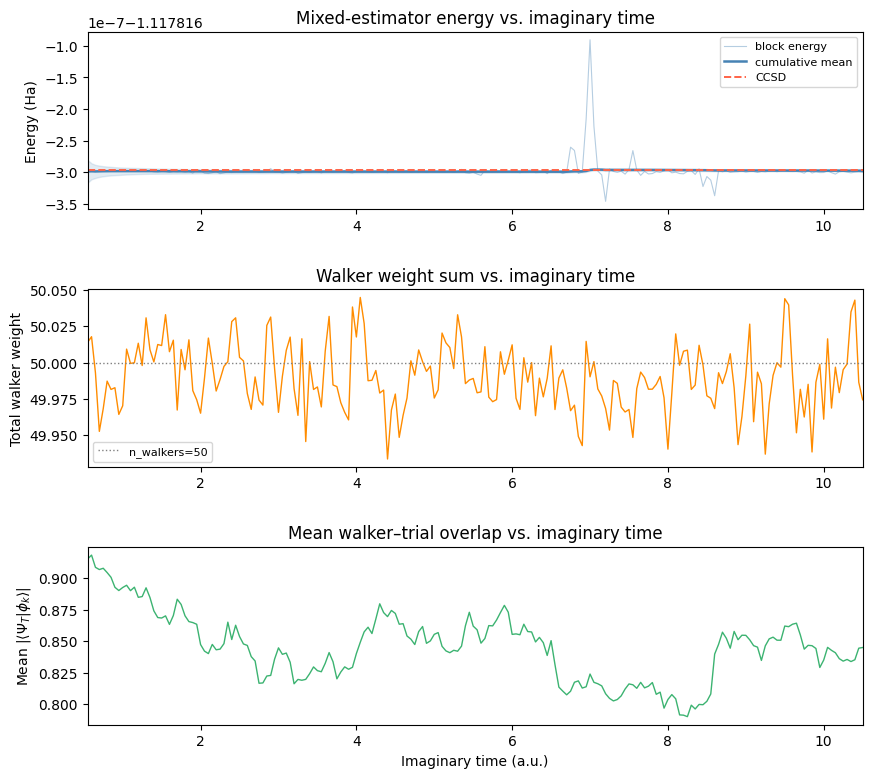

Figure saved to afqmc_h2_propagation.png


In [ ]:

# ── Plot: energy, weights, overlaps vs. imaginary time ────────────────────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(10, 9))
gs  = gridspec.GridSpec(3, 1, hspace=0.45)

# ── panel 1: block energy + cumulative mean ────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(block_times, block_energies, color="steelblue", alpha=0.4, lw=0.8, label="block energy")
ax1.plot(block_times, cum_e, color="steelblue", lw=1.8, label="cumulative mean")
ax1.axhline(mycc.e_tot, color="tomato", lw=1.4, ls="--", label="CCSD")
ax1.set_ylabel("Energy (Ha)")
ax1.set_title("Mixed-estimator energy vs. imaginary time")
ax1.legend(fontsize=8)
ax1.set_xlim(block_times[0], block_times[-1])

# shade ±1σ band around cumulative mean
sigma = np.std(block_energies) / np.sqrt(np.arange(1, params.n_blocks + 1))
ax1.fill_between(block_times, cum_e - sigma, cum_e + sigma, color="steelblue", alpha=0.15)

# ── panel 2: total walker weight ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(block_times, block_weights, color="darkorange", lw=1.0)
# after SR all weights are equalised, so total weight ~ n_walkers * avg_weight
ax2.axhline(params.n_walkers, color="grey", lw=1.0, ls=":", label=f"n_walkers={params.n_walkers}")
ax2.set_ylabel("Total walker weight")
ax2.set_title("Walker weight sum vs. imaginary time")
ax2.legend(fontsize=8)
ax2.set_xlim(block_times[0], block_times[-1])

# ── panel 3: mean |overlap| ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.plot(block_times, block_mean_ovlp, color="mediumseagreen", lw=1.0)
ax3.set_ylabel(r"Mean $|\langle\Psi_T|\phi_k\rangle|$")
ax3.set_xlabel("Imaginary time (a.u.)")
ax3.set_title("Mean walker–trial overlap vs. imaginary time")
ax3.set_xlim(block_times[0], block_times[-1])

plt.show()
